# 13 — Claim Frequency Explainability

## Objectif

Cette étape vise à expliquer le comportement du modèle
XGBoost Poisson utilisé pour prédire la fréquence attendue
des sinistres.

La méthode SHAP est utilisée afin d'étudier :

- l'importance globale des variables ;
- la direction de leurs contributions ;
- les relations non linéaires ;
- des prédictions individuelles.

Les valeurs SHAP décrivent le comportement du modèle
et ne doivent pas être interprétées comme des relations causales.

In [1]:
import pandas as pd
import numpy as np

import json
import joblib
import shap

import matplotlib.pyplot as plt

from pathlib import Path
from scipy import sparse

RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)

c:\Users\user\ai-business-advisor-v2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:

    if path.exists():

        PROCESSED_DIR = path
        break


if PROCESSED_DIR is None:

    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = (
    PROCESSED_DIR.parent
)

METADATA_DIR = (
    DATA_DIR
    / "metadata"
)

ARTIFACTS_DIR = (
    DATA_DIR.parent
    / "artifacts"
)

REPORT_DIR = (
    DATA_DIR.parent
    / "reports"
    / "models"
    / "claim_frequency"
    / "explainability"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
frequency = pd.read_csv(
    PROCESSED_DIR
    / "claim_frequency_modeling_base.csv"
)

split_df = pd.read_csv(
    METADATA_DIR
    / "freMTPL2_split.csv"
)


frequency = frequency.merge(
    split_df,
    on="IDpol",
    how="left",
    validate="one_to_one"
)


development = (
    frequency[
        frequency["split"]
        == "development"
    ]
    .copy()
)

In [4]:
with open(
    METADATA_DIR
    / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:

    feature_manifest = json.load(f)


config = (
    feature_manifest[
        "claim_frequency"
    ]
)

numeric_features = (
    config[
        "numeric_features"
    ]
)

categorical_features = (
    config[
        "categorical_features"
    ]
)

features = (
    numeric_features
    +
    categorical_features
)

In [5]:
X_dev = (
    development[
        features
    ]
    .copy()
)

y_count_dev = (
    development[
        "ClaimNb"
    ]
)

exposure_dev = (
    development[
        "Exposure"
    ]
)

In [6]:
MODEL_PATH = (
    ARTIFACTS_DIR
    / "claim_frequency_xgboost_poisson.joblib"
)

final_model = joblib.load(
    MODEL_PATH
)

print(
    final_model
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['VehPower', 'VehAge',
                                                   'DrivAge', 'BonusMalus',
                                                   'log_density']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Area', 'VehBrand

In [7]:
fitted_preprocessor = (
    final_model
    .named_steps[
        "preprocessor"
    ]
)

fitted_xgb = (
    final_model
    .named_steps[
        "model"
    ]
)

In [8]:
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    "Nombre de features après preprocessing :",
    len(feature_names)
)

print(
    feature_names[:20]
)

Nombre de features après preprocessing : 46
['numeric__VehPower' 'numeric__VehAge' 'numeric__DrivAge'
 'numeric__BonusMalus' 'numeric__log_density' 'categorical__Area_A'
 'categorical__Area_B' 'categorical__Area_C' 'categorical__Area_D'
 'categorical__Area_E' 'categorical__Area_F' 'categorical__VehBrand_B1'
 'categorical__VehBrand_B10' 'categorical__VehBrand_B11'
 'categorical__VehBrand_B12' 'categorical__VehBrand_B13'
 'categorical__VehBrand_B14' 'categorical__VehBrand_B2'
 'categorical__VehBrand_B3' 'categorical__VehBrand_B4']


In [9]:
SHAP_SAMPLE_SIZE = 5000

X_shap_raw = (
    X_dev
    .sample(
        n=min(
            SHAP_SAMPLE_SIZE,
            len(X_dev)
        ),
        random_state=RANDOM_STATE
    )
    .copy()
)

In [10]:
X_shap_transformed = (
    fitted_preprocessor
    .transform(
        X_shap_raw
    )
)


if sparse.issparse(
    X_shap_transformed
):

    X_shap_transformed = (
        X_shap_transformed
        .toarray()
    )

In [11]:
X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names,
    index=X_shap_raw.index
)

X_shap_df.head()

,numeric__VehPower,numeric__VehAge,numeric__DrivAge,numeric__BonusMalus,numeric__log_density,categorical__Area_A,categorical__Area_B,categorical__Area_C,categorical__Area_D,categorical__Area_E,categorical__Area_F,categorical__VehBrand_B1,categorical__VehBrand_B10,categorical__VehBrand_B11,categorical__VehBrand_B12,categorical__VehBrand_B13,categorical__VehBrand_B14,categorical__VehBrand_B2,categorical__VehBrand_B3,categorical__VehBrand_B4,categorical__VehBrand_B5,categorical__VehBrand_B6,categorical__VehGas_Diesel,categorical__VehGas_Regular,categorical__Region_R11,categorical__Region_R21,categorical__Region_R22,categorical__Region_R23,categorical__Region_R24,categorical__Region_R25,categorical__Region_R26,categorical__Region_R31,categorical__Region_R41,categorical__Region_R42,categorical__Region_R43,categorical__Region_R52,categorical__Region_R53,categorical__Region_R54,categorical__Region_R72,categorical__Region_R73,categorical__Region_R74,categorical__Region_R82,categorical__Region_R83,categorical__Region_R91,categorical__Region_R93,categorical__Region_R94
286629,5.0,10.0,36.0,51.0,3.970292,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
585189,6.0,3.0,77.0,50.0,5.690359,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
585740,7.0,11.0,58.0,50.0,5.690359,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117005,5.0,6.0,37.0,50.0,7.180831,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
387828,8.0,5.0,71.0,50.0,6.614726,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [13]:
explainer = shap.TreeExplainer(
    fitted_xgb
)
shap_values = explainer(
    X_shap_df
)


In [14]:
mean_abs_shap = (
    np.abs(
        shap_values.values
    )
    .mean(
        axis=0
    )
)


shap_importance = pd.DataFrame({
    "feature":
        feature_names,

    "mean_abs_shap":
        mean_abs_shap
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

In [15]:
shap_importance.head(
    20
)

,feature,mean_abs_shap
3,numeric__BonusMalus,0.291943
25,categorical__Region_R21,0.155731
42,categorical__Region_R83,0.132352
1,numeric__VehAge,0.127031
32,categorical__Region_R41,0.107241
18,categorical__VehBrand_B3,0.099213
2,numeric__DrivAge,0.092431
4,numeric__log_density,0.077561
8,categorical__Area_D,0.075159
20,categorical__VehBrand_B5,0.071920


In [16]:
shap_importance.to_csv(
    REPORT_DIR
    / "frequency_shap_global_importance.csv",
    index=False
)

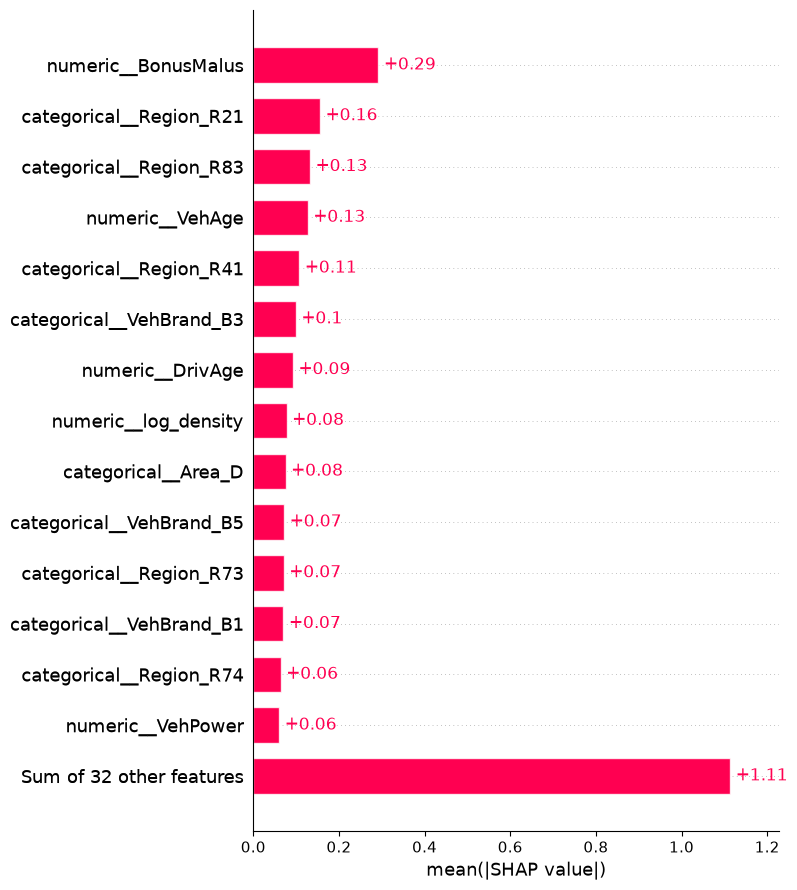

In [17]:
shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "frequency_shap_global_bar.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

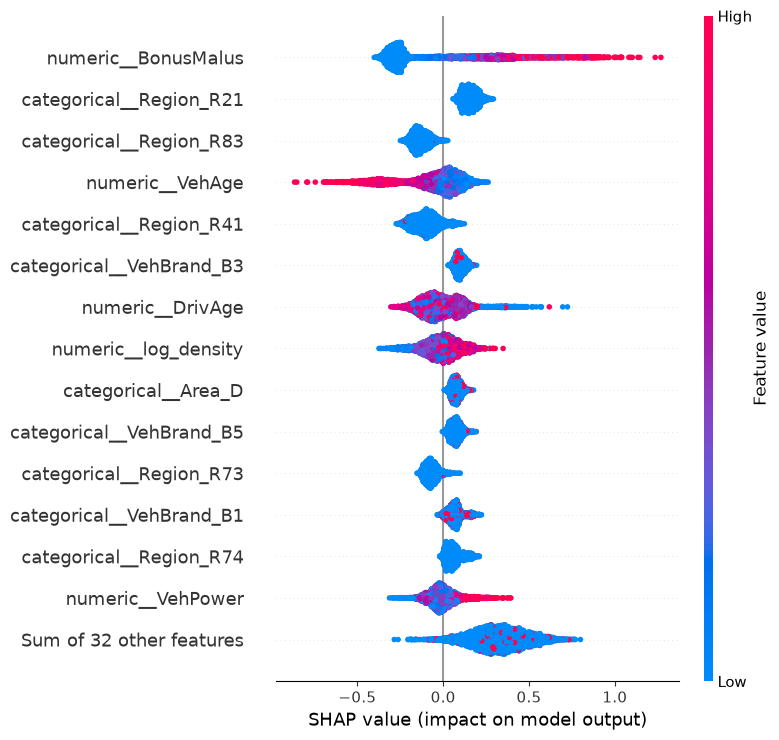

In [18]:
shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "frequency_shap_beeswarm.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [19]:
def get_original_feature(
    feature_name
):

    if feature_name.startswith(
        "numeric__"
    ):

        return feature_name.replace(
            "numeric__",
            ""
        )


    if feature_name.startswith(
        "categorical__"
    ):

        cleaned = feature_name.replace(
            "categorical__",
            ""
        )

        for col in categorical_features:

            if cleaned.startswith(
                col + "_"
            ):

                return col

        return cleaned


    return feature_name

In [20]:
shap_importance[
    "original_feature"
] = (
    shap_importance[
        "feature"
    ]
    .apply(
        get_original_feature
    )
)

In [21]:
grouped_importance = (
    shap_importance
    .groupby(
        "original_feature",
        as_index=False
    )
    .agg(
        mean_abs_shap_sum=(
            "mean_abs_shap",
            "sum"
        )
    )
    .sort_values(
        "mean_abs_shap_sum",
        ascending=False
    )
)


grouped_importance

,original_feature,mean_abs_shap_sum
3,Region,1.149698
5,VehBrand,0.584920
1,BonusMalus,0.291943
0,Area,0.177638
4,VehAge,0.127031
2,DrivAge,0.092431
8,log_density,0.077561
7,VehPower,0.060315
6,VehGas,0.047550


In [22]:
grouped_importance.to_csv(
    REPORT_DIR
    / "frequency_shap_grouped_features.csv",
    index=False
)

In [23]:
sample_predicted_rates = (
    final_model
    .predict(
        X_shap_raw
    )
)

In [24]:
highest_position = int(
    np.argmax(
        sample_predicted_rates
    )
)

In [25]:
high_risk_case = (
    X_shap_raw
    .iloc[
        [highest_position]
    ]
)

In [26]:
high_risk_frequency = float(
    sample_predicted_rates[
        highest_position
    ]
)


print(
    "Predicted frequency :",
    high_risk_frequency
)

print(
    "\nFeatures :"
)

print(
    high_risk_case.T
)

Predicted frequency : 1.8306647539138794

Features :
                  341
VehPower            9
VehAge              0
DrivAge            32
BonusMalus         61
log_density  5.866468
Area                C
VehBrand          B12
VehGas        Regular
Region            R41


In [27]:
selected_index = (
    high_risk_case.index[0]
)

selected_exposure = float(
    development.loc[
        selected_index,
        "Exposure"
    ]
)

In [28]:
expected_claim_count = (
    high_risk_frequency
    *
    selected_exposure
)


print(
    "Predicted frequency :",
    high_risk_frequency
)

print(
    "Exposure :",
    selected_exposure
)

print(
    "Expected claim count :",
    expected_claim_count
)

Predicted frequency : 1.8306647539138794
Exposure : 0.48
Expected claim count : 0.8787190818786621


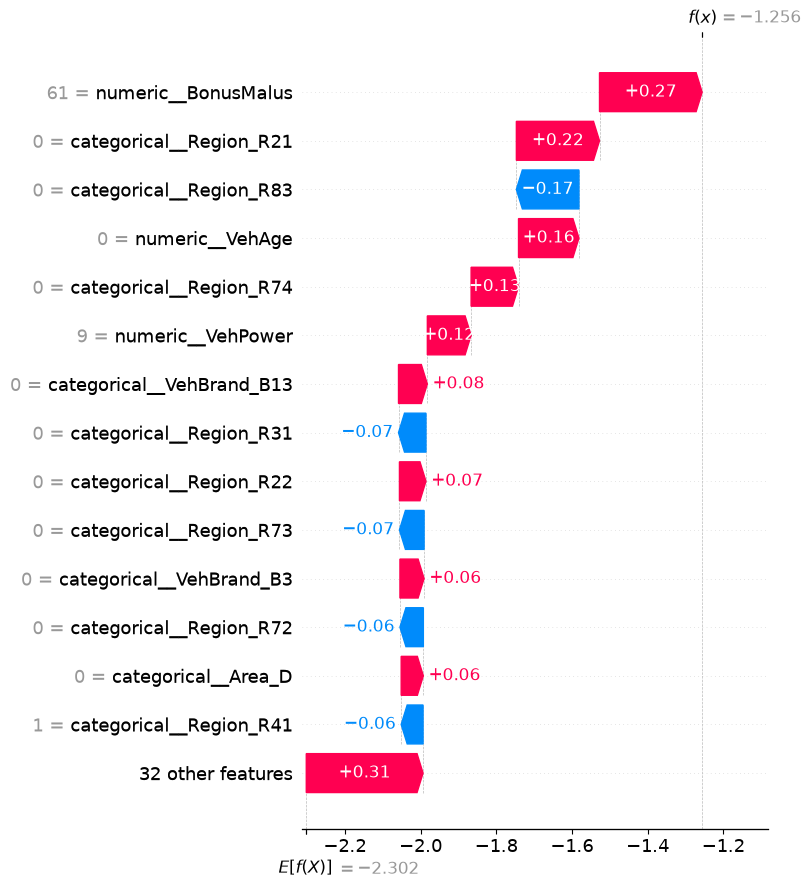

In [29]:
shap.plots.waterfall(
    shap_values[
        highest_position
    ],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "frequency_shap_high_risk_waterfall.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [30]:
lowest_position = int(
    np.argmin(
        sample_predicted_rates
    )
)

low_risk_case = (
    X_shap_raw
    .iloc[
        [lowest_position]
    ]
)

low_risk_frequency = float(
    sample_predicted_rates[
        lowest_position
    ]
)


print(
    "Low-risk predicted frequency :",
    low_risk_frequency
)

print(
    low_risk_case.T
)

Low-risk predicted frequency : 0.009664922952651978
               469092
VehPower            7
VehAge             33
DrivAge            32
BonusMalus         51
log_density  3.912023
Area                A
VehBrand           B3
VehGas        Regular
Region            R91


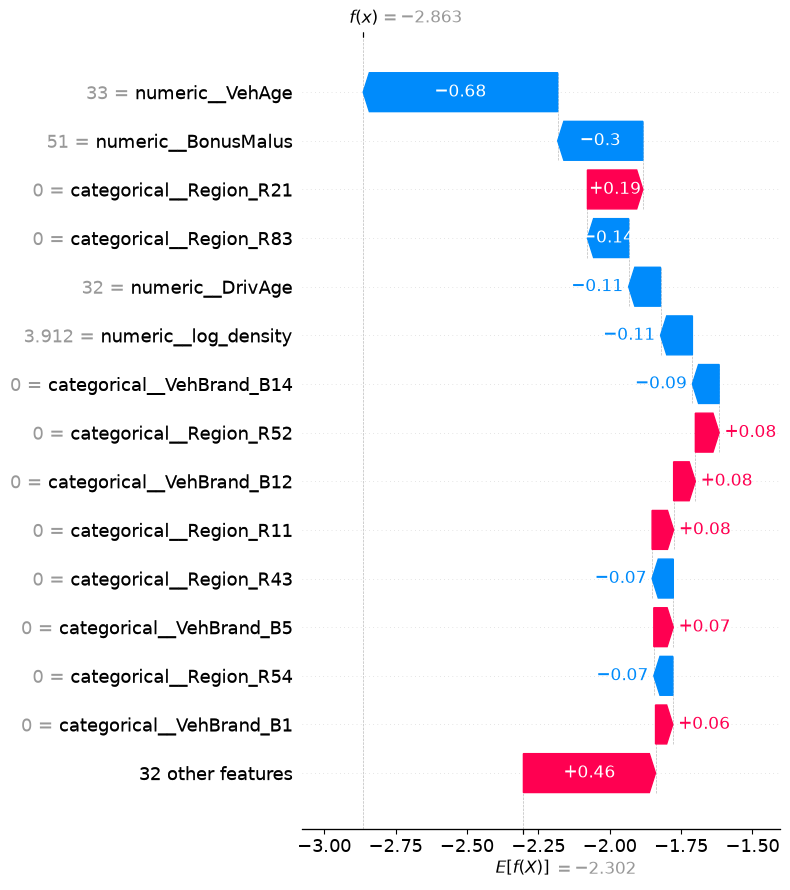

In [31]:
shap.plots.waterfall(
    shap_values[
        lowest_position
    ],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "frequency_shap_low_risk_waterfall.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [32]:
print(
    "=" * 80
)

print(
    "CLAIM FREQUENCY — SHAP RESULTS"
)

print(
    "=" * 80
)


print(
    "\n=== TOP 20 ENCODED FEATURES ==="
)

print(
    shap_importance
    .head(20)
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== GROUPED BUSINESS FEATURES ==="
)

print(
    grouped_importance
    .head(15)
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== HIGH FREQUENCY EXAMPLE ==="
)

print(
    "Predicted frequency :",
    high_risk_frequency
)

print(
    "Exposure :",
    selected_exposure
)

print(
    "Expected claim count :",
    expected_claim_count
)

print(
    "\nFeatures :"
)

print(
    high_risk_case
    .T
    .to_string()
)


print(
    "\n=== LOW FREQUENCY EXAMPLE ==="
)

print(
    "Predicted frequency :",
    low_risk_frequency
)

print(
    "\nFeatures :"
)

print(
    low_risk_case
    .T
    .to_string()
)


print(
    "\nFigures saved in :"
)

print(
    REPORT_DIR
)


print(
    "=" * 80
)

CLAIM FREQUENCY — SHAP RESULTS

=== TOP 20 ENCODED FEATURES ===
                  feature  mean_abs_shap original_feature
      numeric__BonusMalus       0.291943       BonusMalus
  categorical__Region_R21       0.155731           Region
  categorical__Region_R83       0.132352           Region
          numeric__VehAge       0.127031           VehAge
  categorical__Region_R41       0.107241           Region
 categorical__VehBrand_B3       0.099213         VehBrand
         numeric__DrivAge       0.092431          DrivAge
     numeric__log_density       0.077561      log_density
      categorical__Area_D       0.075159             Area
 categorical__VehBrand_B5       0.071920         VehBrand
  categorical__Region_R73       0.070855           Region
 categorical__VehBrand_B1       0.070157         VehBrand
  categorical__Region_R74       0.063732           Region
        numeric__VehPower       0.060315         VehPower
  categorical__Region_R82       0.059418           Region
 categor

## Interprétabilité du modèle de fréquence

Afin d'étudier le comportement du modèle XGBoost Poisson,
une analyse SHAP a été réalisée.

La méthode SHAP permet d'identifier les variables qui contribuent
le plus aux prédictions et d'expliquer des décisions individuelles.

### Importance globale

La variable encodée individuellement présentant la contribution
moyenne la plus importante est `BonusMalus`.

Les informations suivantes jouent également un rôle important :

- Region ;
- VehBrand ;
- Area ;
- VehAge ;
- DrivAge ;
- Density après transformation logarithmique ;
- VehPower ;
- VehGas.

Les variables catégorielles telles que Region et VehBrand étant
transformées par One-Hot Encoding, leur importance est répartie
entre plusieurs modalités.

Une agrégation des contributions des modalités montre que
les informations géographiques et les caractéristiques de marque
sont collectivement fortement utilisées par le modèle.

Cette agrégation doit néanmoins être interprétée avec prudence,
car les variables possédant davantage de modalités disposent
également d'un plus grand nombre de features encodées.

### Rôle de l'exposition

Contrairement au modèle d'occurrence, Exposure n'est pas utilisée
comme feature du modèle de fréquence.

La cible est définie comme :

ClaimNb / Exposure

et Exposure est utilisée comme poids d'apprentissage.

Cette stratégie permet de modéliser les différences intrinsèques
de fréquence entre contrats sans utiliser directement leur durée
d'observation comme caractéristique explicative.

### Exemple de fréquence élevée

Un contrat analysé présente une fréquence prédite de :

1.8307 sinistre par unité d'exposition.

Son exposition est de :

0.48

Le nombre attendu de sinistres pour cette police est donc :

1.8307 × 0.48 ≈ 0.8787.

La fréquence ne doit pas être interprétée comme une probabilité.

Une fréquence supérieure à 1 est mathématiquement possible,
car elle représente un nombre attendu de sinistres par unité
d'exposition.

### Exemple de faible fréquence

Un autre contrat obtient une fréquence prédite de :

0.0097

illustrant la capacité du modèle à différencier fortement
les niveaux de risque du portefeuille.

### Interprétation des contributions

Les valeurs SHAP permettent de déterminer si une caractéristique
contribue à augmenter ou diminuer le score produit par XGBoost.

Dans le cadre de l'objectif Poisson, ces contributions sont liées
à l'espace interne du modèle et ne représentent pas directement
un nombre additionnel de sinistres.

Enfin, les contributions SHAP représentent des associations apprises
par le modèle et ne permettent pas d'établir une relation causale.